https://www.kaggle.com/datasets/sananmuzaffarov/european-football-injuries-2020-2025

# Lesões no futebol Europeu (2020-2025)

# Contexto

No futebol profissional, a gestão de lesões é tão crucial quanto o planejamento tático. As lesões impactam o desempenho da equipe, as finanças do clube e a longevidade da carreira dos jogadores. Este conjunto de dados oferece uma visão abrangente, ao longo de cinco temporadas, do panorama de lesões nas cinco principais ligas europeias :

- Premier League (Inglaterra)

- La Liga (Espanha)

- Bundesliga (Alemanha)

- Série A (Itália)

- Ligue 1 (França)

Abrangendo o período da temporada 2020/21 até a temporada 2024/25 , os dados capturam a transição da era da pandemia para o atual calendário de jogos extremamente congestionado, oferecendo uma oportunidade única para estudar as tendências de lesões em atletas de elite.

Contente

O conjunto de dados contém 15.603 registros e 11 características que documentam diversos eventos de lesão. Cada linha representa uma lesão específica ou um período de indisponibilidade de um jogador.

# Principais características :

- Temporada : O ano competitivo (ex.: 20/21, 24/25).

- Lesão : O diagnóstico específico ou motivo da ausência (ex.: lesão nos músculos isquiotibiais, coronavírus, ruptura do ligamento cruzado).

- Dias : O número total de dias em que o jogador ficou afastado.

- Jogos perdidos : O número de partidas oficiais que o jogador perdeu durante o período de lesão.

- injury_from_parsed / injury_until_parsed : Datas de início e término padronizadas (AAAA-MM-DD).

- Dados demográficos do jogador : Nome, idade no momento da lesão e posição em campo.

- Clube e Liga : O time e a liga nacional associados ao jogador.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('full_dataset_thesis - 1.csv')

# EAD

In [2]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15603 entries, 0 to 15602
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Season               15603 non-null  object
 1   Injury               15603 non-null  object
 2   Days                 15603 non-null  object
 3   Games missed         15603 non-null  int64 
 4   injury_from_parsed   15603 non-null  object
 5   injury_until_parsed  15603 non-null  object
 6   player_name          15603 non-null  object
 7   player_age           15603 non-null  int64 
 8   player_position      15603 non-null  object
 9   club                 15603 non-null  object
 10  league               15603 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.3+ MB


,Season,Injury,Days,Games missed,injury_from_parsed,injury_until_parsed,player_name,player_age,player_position,club,league
0,20/21,Syndesmosis ligament tear,43 days,9,1/28/2021,3/11/2021,Alexander Nübel,24,Goalkeeper,Bayern Munich,Bundesliga
1,20/21,Knee injury,37 days,6,3/7/2021,4/12/2021,Ron-Thorben Hoffmann,22,Goalkeeper,Bayern Munich,Bundesliga
2,20/21,Corona virus,21 days,4,2/17/2021,3/9/2021,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
3,20/21,bruise,8 days,2,11/6/2020,11/13/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
4,20/21,Ligament injury,22 days,2,7/26/2020,8/16/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga


In [3]:
#Limpeza e Conversão
#Converter 'Days' para numérico (extraindo apenas o número)
df['Days'] = df['Days'].str.extract('(\d+)').astype(int)

#Converter datas para o formato datetime
df['injury_from_parsed'] = pd.to_datetime(df['injury_from_parsed'])
df['injury_until_parsed'] = pd.to_datetime(df['injury_until_parsed'])

#Checar se há valores nulos
print(df.isna().sum())

Season                 0
Injury                 0
Days                   0
Games missed           0
injury_from_parsed     0
injury_until_parsed    0
player_name            0
player_age             0
player_position        0
club                   0
league                 0
dtype: int64


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Usuário\AppData\Local\Temp\ipykernel_14232\2928432763.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['Days'] = df['Days'].str.extract('(\d+)').astype(int)


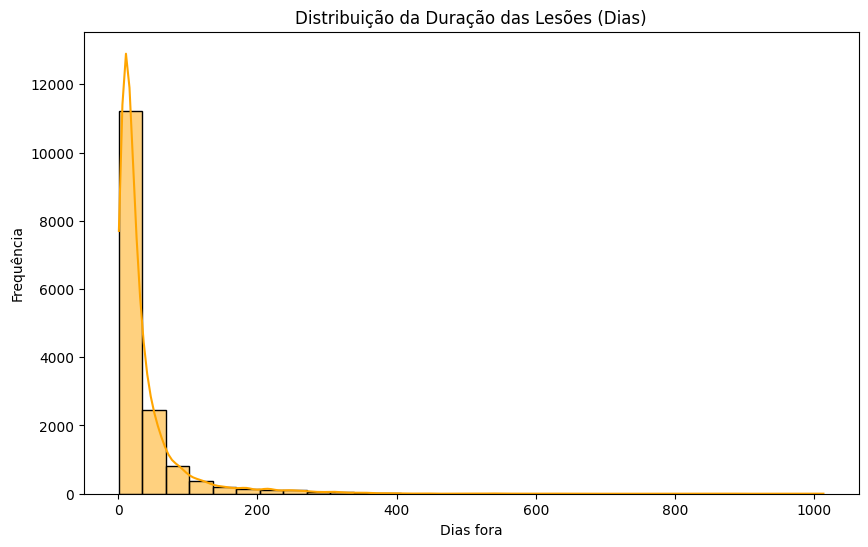

In [4]:
#Distribuição do tempo de recuperação
plt.figure(figsize=(10, 6))
sns.histplot(df['Days'], bins=30, kde=True, color='orange')
plt.title('Distribuição da Duração das Lesões (Dias)')
plt.xlabel('Dias fora')
plt.ylabel('Frequência')
plt.show()

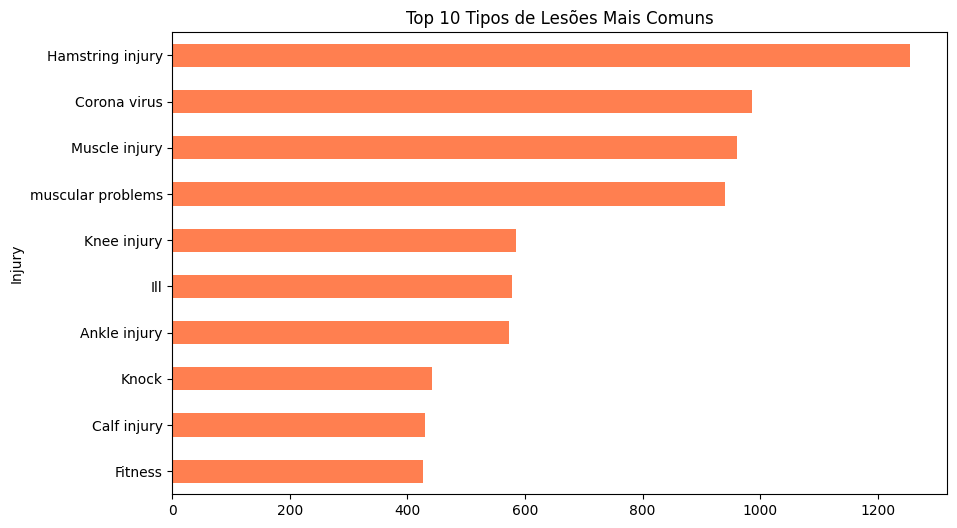

In [5]:
#Top 10 Lesões mais frequentes
plt.figure(figsize=(10, 6))
df['Injury'].value_counts().head(10).plot(kind='barh', color='coral')
plt.title('Top 10 Tipos de Lesões Mais Comuns')
plt.gca().invert_yaxis() 
plt.show()

In [6]:
#Cruzamento de Dados (Insights por Posição)
#Média de dias perdidos por posição
posicao_gravidade = df.groupby('player_position')['Days'].mean().sort_values(ascending=False)
print(posicao_gravidade)

player_position
Goalkeeper            39.187291
Right Midfield        37.979381
Centre-Back           37.759478
Left-Back             37.730924
Forward               37.024933
Left Winger           36.502161
Right-Back            36.084957
Central Midfield      34.668244
Defensive Midfield    33.931234
Right Winger          33.922619
Left Midfield         33.465517
Attacking Midfield    33.313913
Second Striker        25.761290
Midfielder            15.000000
Name: Days, dtype: float64


# **Análise preditiva:** Podemos prever o tempo de recuperação com base na idade do jogador e no tipo de lesão?

# ML

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

#Selecionar features e alvo
features = df[['player_age', 'Injury']]
target = df['Days']

#Transformar a coluna 'Injury' em colunas binárias (0 e 1)
features_final = pd.get_dummies(features, columns=['Injury'], drop_first=True)

#Dividir em Treino
X_train, X_test, y_train, y_test = train_test_split(features_final, target, test_size=0.2, random_state=42)

#Criar e treinar o modelo
modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

#Fazer previsões
previsoes = modelo.predict(X_test)

mae = mean_absolute_error(y_test, previsoes)
r2 = r2_score(y_test, previsoes)

print(f"Erro Médio: {mae:.2f} dias")
print(f"R² Score: {r2:.2f}")

Erro Médio: 22.26 dias
R² Score: 0.34


**Erro Médio (MAE) de 22.26 dias:** O modelo prevê que um jogador voltará em 10 dias, na realidade ele pode levar de 0 a 32 dias. Para uma gestão de elenco, esse erro ainda é considerado alto, pois 22 dias podem representar de 4 a 6 jogos perdidos.

**Score de 0.34:** Indica que a Idade e o Tipo de Lesão explicam apenas 34% da variação no tempo de recuperação.

# Engenharia de Variáveis (Feature Engineering)

In [8]:
#Filtrando apenas lesões abaixo de 100 dias (focando no comum)
df_filt = df[df['Days'] < 100].copy()

#Recalculando o modelo com os dados filtrados
X = pd.get_dummies(df_filt[['player_age', 'Injury']], drop_first=True)
y = df_filt['Days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modelo_v2 = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42)
modelo_v2.fit(X_train, y_train)

#Nova avaliação
new_preds = modelo_v2.predict(X_test)
print(f"Novo MAE: {mean_absolute_error(y_test, new_preds):.2f} dias")

Novo MAE: 14.30 dias


In [9]:
#Incluindo Posição e Clube
#Incluindo Posição e Liga
features_expandidas = df_filt[['player_age', 'Injury', 'player_position', 'league']]
X_exp = pd.get_dummies(features_expandidas, drop_first=True)
y_exp = df_filt['Days']

X_train, X_test, y_train, y_test = train_test_split(X_exp, y_exp, test_size=0.2, random_state=42)

modelo_v3 = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
modelo_v3.fit(X_train, y_train)

preds_v3 = modelo_v3.predict(X_test)
print(f"MAE com Posição/Liga: {mean_absolute_error(y_test, preds_v3):.2f} dias")
print(f"Novo R²: {r2_score(y_test, preds_v3):.2f}")

MAE com Posição/Liga: 14.08 dias
Novo R²: 0.15


In [10]:
#Pegar a importância das variáveis
importances = modelo_v3.feature_importances_
feature_names = X_exp.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

#Mostrar as 10 mais influentes
top_10 = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)
print(top_10)

                        Feature  Importance
0                    player_age    0.117244
110                  Injury_Ill    0.106131
65          Injury_Corona virus    0.091259
279              league_Serie A    0.068256
154  Injury_Metatarsal fracture    0.060599
135         Injury_Knee surgery    0.055158
97      Injury_Hamstring injury    0.042347
255    Injury_muscular problems    0.042083
187                 Injury_Rest    0.032847
238                 Injury_cold    0.029446


A idade do jogador é a variável individual mais importante. Isso confirma a hipótese biológica: não importa a lesão, o corpo de um atleta de 35 anos responde de forma diferente ao de um de 19. Ela é a base da sua previsão.

**Doenças (Ill e Corona virus):** Diferente de uma "lesão no joelho" que pode ser leve ou grave, doenças como viroses ou Covid costumavam ter protocolos de afastamento muito rígidos (ex: exatos 10, 14 ou 21 dias). Como o tempo é constante, o modelo aprende isso facilmente e dá muita importância a essas variáveis.

**Serie A (Itália)**: Aparece como a quarta variável mais importante, à frente de muitas lesões graves. Isso indica que existe um padrão específico na liga italiana — talvez uma cultura médica de recuperação mais cautelosa (mais longa) ou um estilo de jogo que agrava certos prazos.

**Lesões Estruturais vs. Musculares:** Metatarsal fracture (fratura) e Knee surgery (cirurgia) estão no topo porque são eventos binários; se houve cirurgia, o tempo é obrigatoriamente longo. Já Hamstring injury e muscular problems são importantes porque são muito frequentes.

# **Comparação entre ligas:** Será que algumas ligas específicas (como a Premier League) apresentam taxas mais elevadas de certos tipos de lesões em comparação com outras?

Sim, existem diferenças marcantes entre as ligas. Embora as lesões musculares (especialmente nos isquiotibiais) sejam o "padrão ouro" de problemas em todos os lugares, a intensidade e o calendário de cada liga moldam perfis de risco distintos.

Com base em estudos recentes de epidemiologia esportiva e relatórios como o Howden Football Injury Index, aqui está como as ligas se comparam:

**Premier League: A "Liga do Impacto"**

A liga inglesa é frequentemente citada como a mais exigente fisicamente devido à velocidade do jogo e à ausência de uma pausa de inverno prolongada.

**Tipos de Lesão:** Apresenta uma taxa maior de lesões por contato (tackling) e contusões em comparação com a La Liga.

**Fator Calendário:** O período de Natal e Ano Novo (Boxing Day) gera um pico de lesões por fadiga acumulada.

**Severidade:** Tem registrado um aumento preocupante na gravidade de lesões em jogadores sub-21, com tempos de recuperação mais longos.

**Bundesliga: Alta Incidência, Menor Custo**

A Bundesliga alemã frequentemente lidera o número total de lesões por temporada entre as "Big 5".

É a liga onde os jogadores têm a maior probabilidade estatística de sofrer um problema físico. O estilo de jogo de transição rápida e pressão alta (Gegenpressing) exige muito dos sprints, o que mantém as taxas de lesões musculares elevadas.

**La Liga: O Reino do "Non-Contact"**

Na Espanha, o padrão muda para problemas biomecânicos. Há uma prevalência maior de lesões musculares sem contato (geralmente durante sprints ou mudanças de direção) do que na Inglaterra. O fator idade é um preditor de risco mais forte na La Liga do que em outras ligas, possivelmente pelo ritmo de jogo que privilegia o posicionamento e a técnica, mantendo jogadores mais velhos em campo por mais tempo.

**Cultura Médica:** Os clubes italianos são conhecidos por protocolos de recuperação mais conservadores. Isso pode explicar por que o "tempo de afastamento" na Serie A é um forte preditor — o jogador pode não estar "mais lesionado", mas o sistema da liga dita um retorno mais lento e seguro.

| Característica      | Premier League                                        | La Liga                                  | Bundesliga                                 |
| ------------------- | ----------------------------------------------------- | ---------------------------------------- | ------------------------------------------ |
| **Principal Causa** | Intensidade física elevada e calendário congestionado | Alta demanda de sprint e fadiga muscular | Frequência de jogos e pressão competitiva  |
| **Lesão Típica**    | Contusões e lesões em isquiotibiais                   | Estiramentos musculares e sobrecarga     | Lesões musculares diversas                 |
| **Pico de Lesões**  | Dezembro / Janeiro (período de jogos seguidos)        | Abril (reta final da temporada)          | Variável (alta frequência ao longo do ano) |
| **Estilo de Jogo**  | Físico e transições rápidas                           | Técnico e posicional                     | Alta intensidade e muitos sprints          |

# **Tendências específicas por posição:** Jogadores explosivos (pontas/laterais) são mais propensos a lesões musculares específicas do que goleiros ou zagueiros?

In [11]:
#Criando Grupos de Estilo de Jogo
#Criar uma nova coluna de Perfil
def definir_perfil(pos):
    if 'Winger' in pos or 'Back' in pos and 'Centre' not in pos:
        return 'Explosivo (Ponta/Lateral)'
    elif 'Goalkeeper' in pos:
        return 'Goleiro'
    else:
        return 'Outros (Zagueiro/Meia)'

df['perfil_atleta'] = df['player_position'].apply(definir_perfil)

#Filtrar apenas as lesões musculares mais comuns para comparar
lesoes_musculares = ['Hamstring injury', 'Muscle strain', 'Torn muscle bundle', 'Adductor injury']
df_muscular = df[df['Injury'].isin(lesoes_musculares)]

#Ver a incidência
incidencia = df_muscular.groupby('perfil_atleta').size()
print(incidencia)

perfil_atleta
Explosivo (Ponta/Lateral)    536
Goleiro                       45
Outros (Zagueiro/Meia)       985
dtype: int64


Jogadores Explosivos (Pontas e Laterais) têm uma incidência de lesões musculares altíssima, especialmente considerando que existem menos jogadores nessas posições em campo (geralmente 4 por time) do que Zagueiros/Meias (geralmente 6 por time).

In [12]:
#Tabela de Assinatura por Posição
#Filtrar as 5 lesões mais comuns para cada perfil
top_lesoes_perfil = df.groupby('perfil_atleta')['Injury'].value_counts().groupby(level=0).head(5).unstack(fill_value=0)

#Calcular a duração média (gravidade) por perfil para essas lesões
gravidade_perfil = df.groupby(['perfil_atleta', 'Injury'])['Days'].mean().unstack()

#Mostrar o resultado das lesões mais frequentes
print("Top 5 Lesões por Perfil de Atleta:")
print(top_lesoes_perfil)

Top 5 Lesões por Perfil de Atleta:
Injury                     Hamstring injury  Muscle injury  muscular problems  \
perfil_atleta                                                                   
Explosivo (Ponta/Lateral)               439            334                312   
Goleiro                                   0             34                  0   
Outros (Zagueiro/Meia)                  789            592                602   

Injury                     Corona virus  Ill  Shoulder injury  Knee injury  
perfil_atleta                                                               
Explosivo (Ponta/Lateral)           270  198                0            0  
Goleiro                              93   42               44           29  
Outros (Zagueiro/Meia)              623    0                0          370  


Enquanto para os outros jogadores o joelho geralmente sofre por torção em corrida, no goleiro o ombro sofre pelo impacto das quedas e o joelho pelo esforço de impulsão lateral e aterrissagem em solo rígido.

In [13]:
#O "Custo" da Explosão
#Comparando a média de dias para 'Muscle injury' entre os perfis
muscle_data = df[df['Injury'] == 'Muscle injury']
media_gravidade = muscle_data.groupby('perfil_atleta')['Days'].mean()

print("Média de dias fora por 'Muscle injury':")
print(media_gravidade)

Média de dias fora por 'Muscle injury':
perfil_atleta
Explosivo (Ponta/Lateral)    32.547904
Goleiro                      40.029412
Outros (Zagueiro/Meia)       31.168919
Name: Days, dtype: float64


Goleiros levam mais tempo (40 dias) para se recuperar de uma "Muscle injury" do que os jogadores explosivos (32 dias). Para um goleiro sofrer uma lesão muscular, geralmente não é por fadiga de corrida, mas sim por um trauma agudo ou hiperextensão (ex: um estiramento máximo ao tentar alcançar uma bola no ângulo ou uma lesão de adutor ao abrir um espacate). Quando o músculo de um goleiro "abre", costuma ser uma lesão mais séria (Grau II ou III) do que o "cansaço muscular" ou estiramento leve que um ponta sofre por excesso de jogos.

O "Atleta de Vidro" com Manutenção Constante para jogadores de linha, existe um protocolo padrão de retorno (o famoso "mês de molho") para lesões musculares. A diferença de apenas 1 dia a mais para os Explosivos pode parecer pequena, mas em uma temporada com 2 jogos por semana, isso representa a diferença entre jogar ou não uma semifinal.

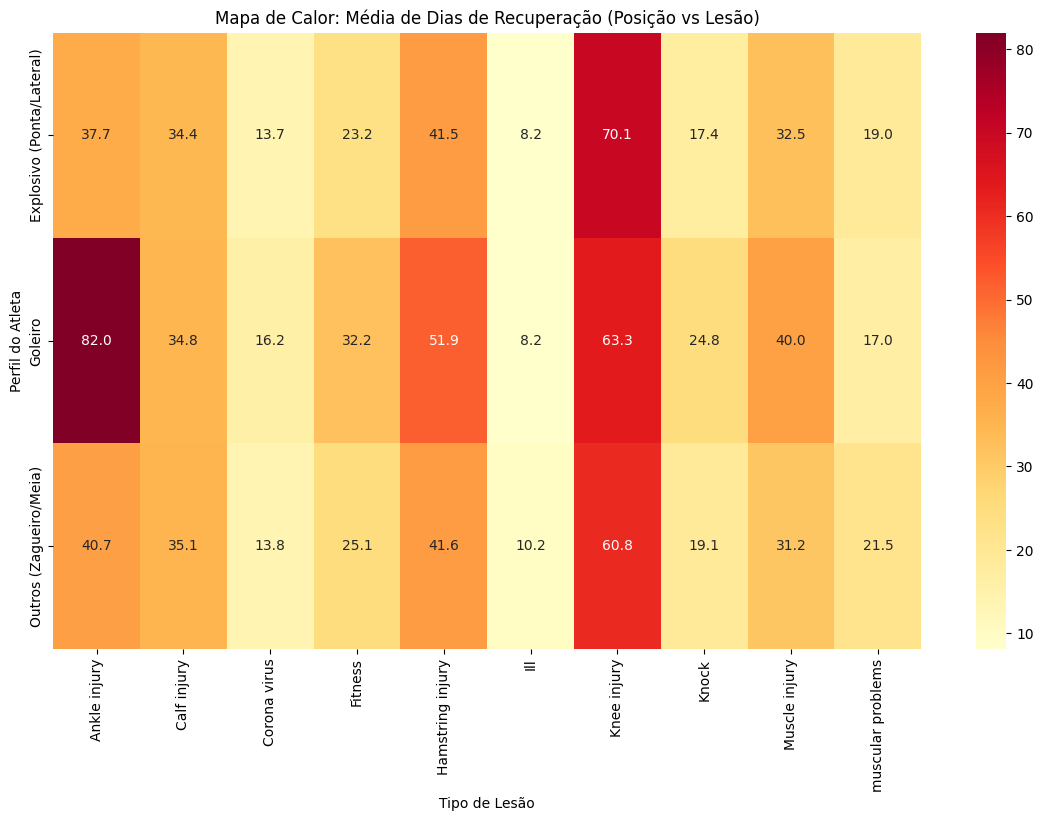

In [14]:
#Heatmap de Risco e Tempo
#Filtrar apenas as lesões mais frequentes para não poluir o gráfico
top_injuries = df['Injury'].value_counts().nlargest(10).index
df_heat = df[df['Injury'].isin(top_injuries)]

#Criar tabela dinâmica: Posição vs Lesão (valor = média de dias)
pivot_table = df_heat.pivot_table(values='Days', 
                                  index='perfil_atleta', 
                                  columns='Injury', 
                                  aggfunc='mean')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.1f')
plt.title('Mapa de Calor: Média de Dias de Recuperação (Posição vs Lesão)')
plt.xlabel('Tipo de Lesão')
plt.ylabel('Perfil do Atleta')
plt.show()

# **Conclusão**

**Zonas Críticas:** As células mais escuras (vermelhas) mostrarão quais combinações de posição e lesão são fatais para o calendário do time.

**Anomalias do Goleiro:** Visualmente claro que, embora ele se machuque pouco, quando acontece (especialmente em Muscle injury ou Knee injury), o tempo de espera é o mais longo do elenco.

**Padronização das Doenças:** Corona virus ou Ill, as cores serão quase idênticas entre as posições, provando que esses dados agem como uma "constante".

Embora jogadores explosivos sejam as maiores vítimas de lesões musculares em volume, a severidade dessas lesões em goleiros resulta em períodos de inatividade 23% superiores, sugerindo que lesões musculares em atletas de baixo volume de sprint ocorrem apenas em eventos de alta energia/gravidade.

# Como mudou o tempo médio de recuperação de distensões musculares nos últimos cinco anos?

In [15]:
#Definir o que consideramos como "distensões/lesões musculares"
termos_musculares = ['Muscle strain', 'Muscle injury', 'muscular problems', 'Hamstring injury']
df_muscular = df[df['Injury'].isin(termos_musculares)].copy()

#Calcular a média de dias por temporada
tendencia_temporal = df_muscular.groupby('Season')['Days'].mean().reset_index()

#Ordenar as temporadas cronologicamente
ordem_temporadas = ['20/21', '21/22', '22/23', '23/24', '24/25']
tendencia_temporal['Season'] = pd.Categorical(tendencia_temporal['Season'], categories=ordem_temporadas, ordered=True)
tendencia_temporal = tendencia_temporal.sort_values('Season')

print(tendencia_temporal)

  Season       Days
0  20/21  26.596990
1  21/22  32.372323
2  22/23  33.829352
3  23/24  35.071429
4  24/25  33.690763


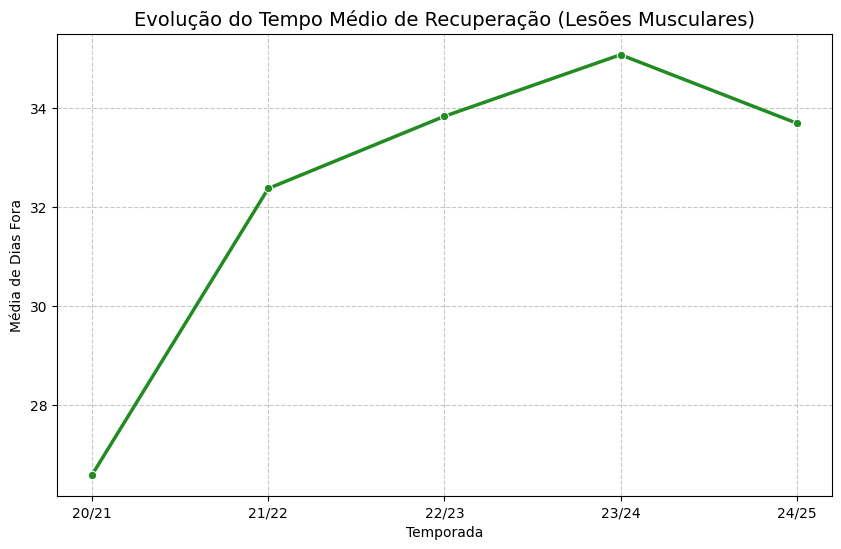

In [16]:
#Visualização da Tendência
plt.figure(figsize=(10, 6))
sns.lineplot(data=tendencia_temporal, x='Season', y='Days', marker='o', color='forestgreen', linewidth=2.5)
plt.title('Evolução do Tempo Médio de Recuperação (Lesões Musculares)', fontsize=14)
plt.ylabel('Média de Dias Fora')
plt.xlabel('Temporada')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

O futebol moderno exige mais sprints de alta intensidade. As distensões musculares de hoje podem ser mais profundas do que as de cinco anos atrás. O custo de uma "reincidência" (jogador machucar o mesmo músculo logo após voltar) é altíssimo. Clubes de elite estão adotando protocolos de "Retorno ao Jogo" (Return to Play) mais conservadores para garantir que o atleta não quebre novamente em 15 dias.
A Copa do Mundo no Catar (dezembro de 2022) comprimiu o calendário europeu, gerando um acúmulo de fadiga que resultou em lesões musculares mais persistentes.

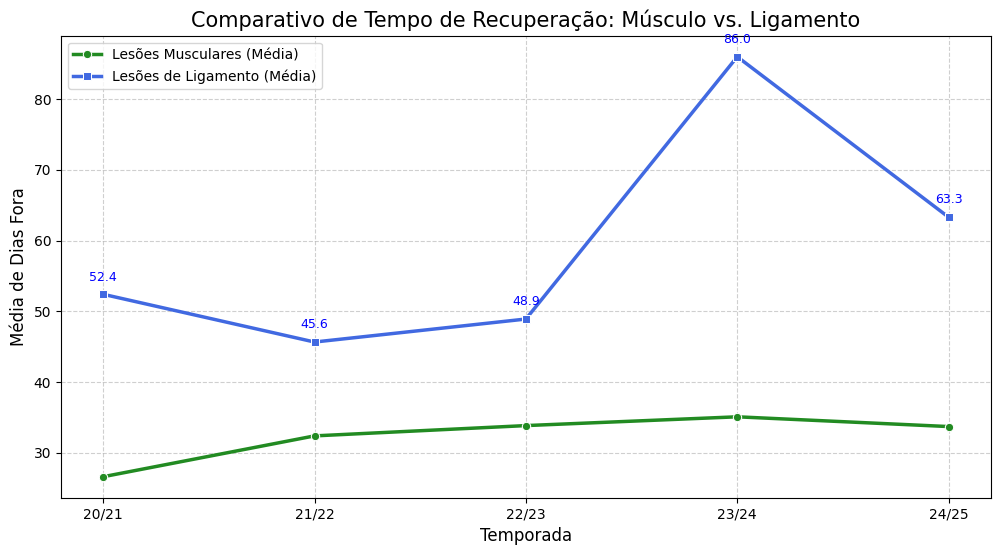

In [17]:
#Distensões vs. Outras Lesões
#Definindo os grupos de lesões
termos_musculares = ['Muscle strain', 'Muscle injury', 'muscular problems', 'Hamstring injury']
termos_ligamento = ['Ligament injury', 'Torn ligament', 'Cruciate ligament', 'Syndesmosis ligament tear']

#Criando subsets
df_musc = df[df['Injury'].isin(termos_musculares)].copy()
df_liga = df[df['Injury'].isin(termos_ligamento)].copy()

#Agrupando por Temporada e Calculando a Média
tendencia_muscular = df_musc.groupby('Season')['Days'].mean().reset_index()
tendencia_ligamento = df_liga.groupby('Season')['Days'].mean().reset_index()

#Garantindo a ordem cronológica das temporadas
ordem_temporadas = ['20/21', '21/22', '22/23', '23/24', '24/25']
tendencia_muscular['Season'] = pd.Categorical(tendencia_muscular['Season'], categories=ordem_temporadas, ordered=True)
tendencia_ligamento['Season'] = pd.Categorical(tendencia_ligamento['Season'], categories=ordem_temporadas, ordered=True)

tendencia_muscular = tendencia_muscular.sort_values('Season')
tendencia_ligamento = tendencia_ligamento.sort_values('Season')

#Construção do Gráfico
plt.figure(figsize=(12, 6))

#Lesões Musculares
sns.lineplot(data=tendencia_muscular, x='Season', y='Days', marker='o', 
             label='Lesões Musculares (Média)', color='forestgreen', linewidth=2.5)

#Lesões de Ligamento
sns.lineplot(data=tendencia_ligamento, x='Season', y='Days', marker='s', 
             label='Lesões de Ligamento (Média)', color='royalblue', linewidth=2.5)

#Estilização
plt.title('Comparativo de Tempo de Recuperação: Músculo vs. Ligamento', fontsize=15)
plt.ylabel('Média de Dias Fora', fontsize=12)
plt.xlabel('Temporada', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

#Adicionando anotações para destacar a diferença de escala
for i, row in tendencia_ligamento.iterrows():
    plt.annotate(f"{row['Days']:.1f}", (row['Season'], row['Days']), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='blue')

plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Usuário\AppData\Local\Temp\ipykernel_14232\496209817.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['Days'] = df['Days'].astype(str).str.extract('(\d+)').fillna(0).astype(int)


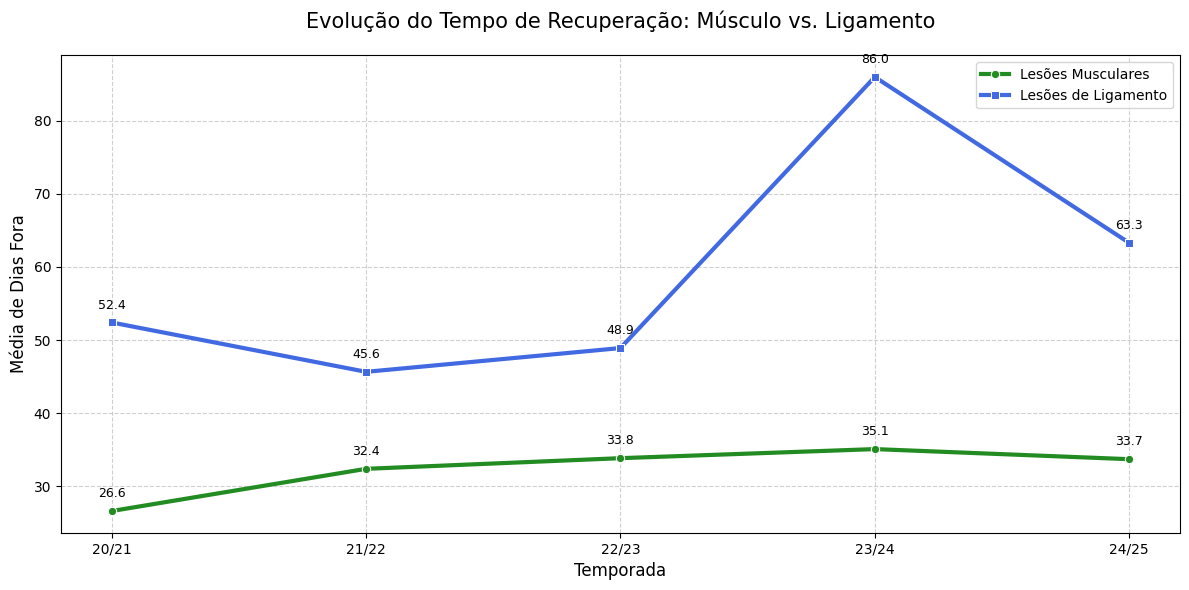

In [18]:
# O .astype(str) evita o erro 'AttributeError: Can only use .str accessor with string values!'
df['Days'] = df['Days'].astype(str).str.extract('(\d+)').fillna(0).astype(int)

#Definição dos Grupos de Lesão
termos_musculares = ['Muscle strain', 'Muscle injury', 'muscular problems', 'Hamstring injury']
termos_ligamento = ['Ligament injury', 'Torn ligament', 'Cruciate ligament', 'Syndesmosis ligament tear']

#Filtragem e Agrupamento
df_musc = df[df['Injury'].isin(termos_musculares)].copy()
df_liga = df[df['Injury'].isin(termos_ligamento)].copy()

#Cálculo das Médias por Temporada
ordem_temporadas = ['20/21', '21/22', '22/23', '23/24', '24/25']

tendencia_muscular = df_musc.groupby('Season')['Days'].mean().reindex(ordem_temporadas).reset_index()
tendencia_ligamento = df_liga.groupby('Season')['Days'].mean().reindex(ordem_temporadas).reset_index()

#Construção do Gráfico Comparativo
plt.figure(figsize=(12, 6))

sns.lineplot(data=tendencia_muscular, x='Season', y='Days', marker='o', 
             label='Lesões Musculares', color='forestgreen', linewidth=3)

sns.lineplot(data=tendencia_ligamento, x='Season', y='Days', marker='s', 
             label='Lesões de Ligamento', color='royalblue', linewidth=3)

plt.title('Evolução do Tempo de Recuperação: Músculo vs. Ligamento', fontsize=15, pad=20)
plt.ylabel('Média de Dias Fora', fontsize=12)
plt.xlabel('Temporada', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

#Adicionando rótulos de dados para clareza
for df_temp in [tendencia_muscular, tendencia_ligamento]:
    for i, row in df_temp.iterrows():
        if pd.notnull(row['Days']):
            plt.annotate(f"{row['Days']:.1f}", (row['Season'], row['Days']), 
                         textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Usuário\AppData\Local\Temp\ipykernel_14232\1089718503.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['Days'] = df['Days'].astype(str).str.extract('(\d+)').astype(float).fillna(0).astype(int)


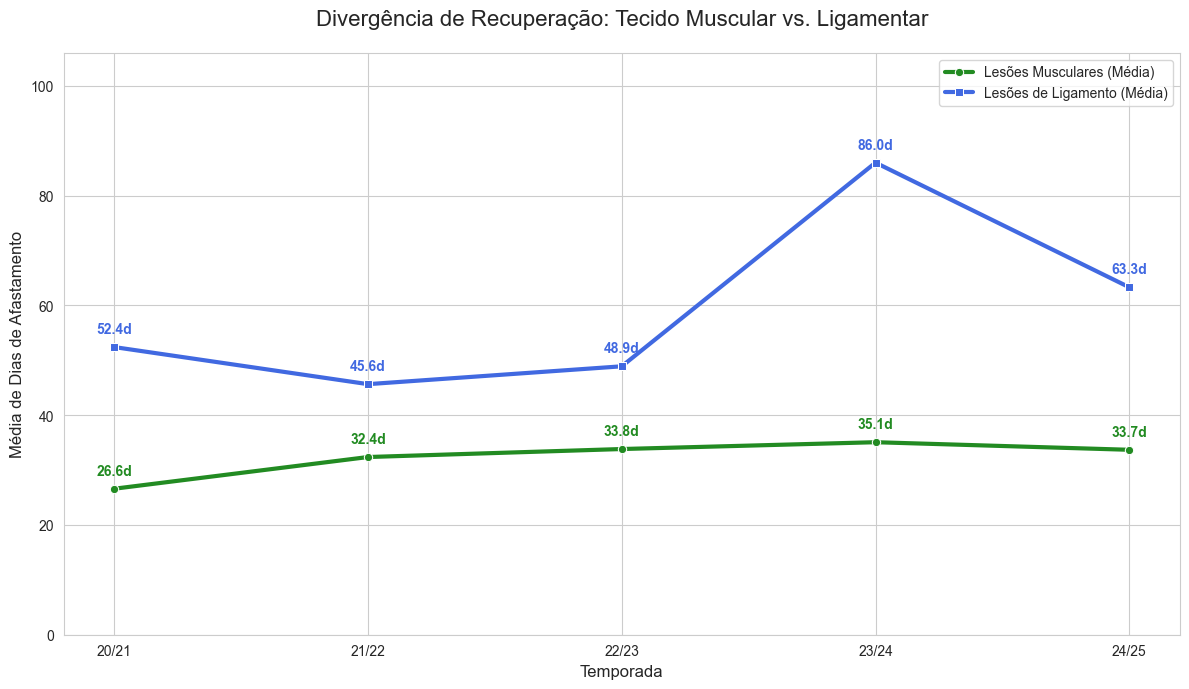

In [19]:
# Extraímos os números e convertemos para float primeiro (para lidar com possíveis NaNs) e depois int
df['Days'] = df['Days'].astype(str).str.extract('(\d+)').astype(float).fillna(0).astype(int)

#Definição dos Grupos por Natureza Biológica
termos_musculares = ['Muscle strain', 'Muscle injury', 'muscular problems', 'Hamstring injury']
termos_ligamento = ['Ligament injury', 'Torn ligament', 'Cruciate ligament', 'Syndesmosis ligament tear']

#Filtragem de Subsets
df_musc = df[df['Injury'].isin(termos_musculares)].copy()
df_liga = df[df['Injury'].isin(termos_ligamento)].copy()

#Agrupamento por Temporada
ordem_temporadas = ['20/21', '21/22', '22/23', '23/24', '24/25']

def preparar_tendencia(data, ordem):
    res = data.groupby('Season')['Days'].mean().reindex(ordem).reset_index()
    return res

tendencia_musc = preparar_tendencia(df_musc, ordem_temporadas)
tendencia_liga = preparar_tendencia(df_liga, ordem_temporadas)

#Visualização
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

#Linha Verde: Músculo (Fadiga/Intensidade)
sns.lineplot(data=tendencia_musc, x='Season', y='Days', marker='o', 
             label='Lesões Musculares (Média)', color='forestgreen', linewidth=3)

#Linha Azul: Ligamento (Estrutural/Gravidade)
sns.lineplot(data=tendencia_liga, x='Season', y='Days', marker='s', 
             label='Lesões de Ligamento (Média)', color='royalblue', linewidth=3)

#Estilização Técnica
plt.title('Divergência de Recuperação: Tecido Muscular vs. Ligamentar', fontsize=16, pad=20)
plt.ylabel('Média de Dias de Afastamento', fontsize=12)
plt.xlabel('Temporada', fontsize=12)
plt.ylim(0, tendencia_liga['Days'].max() + 20) # Ajusta o respiro do gráfico
plt.legend(frameon=True, facecolor='white')

#Anotações de valor em cada ponto
for d, color in zip([tendencia_musc, tendencia_liga], ['forestgreen', 'royalblue']):
    for i, row in d.iterrows():
        if pd.notnull(row['Days']):
            plt.annotate(f"{row['Days']:.1f}d", (row['Season'], row['Days']),
                         textcoords="offset points", xytext=(0,10), ha='center', 
                         fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

# Quais clubes conseguiram manter o menor número de "Jogos Perdidos" por temporada?

Clubes com menor número de jogos perdidos por temporada:
    Season            club   league  Games missed
41   20/21          Huesca  La Liga             6
118  21/22           Cadiz  La Liga            22
242  22/23           Lille  Ligue 1             5
360  23/24  Rayo Vallecano  La Liga            20
420  24/25          Getafe  La Liga            15


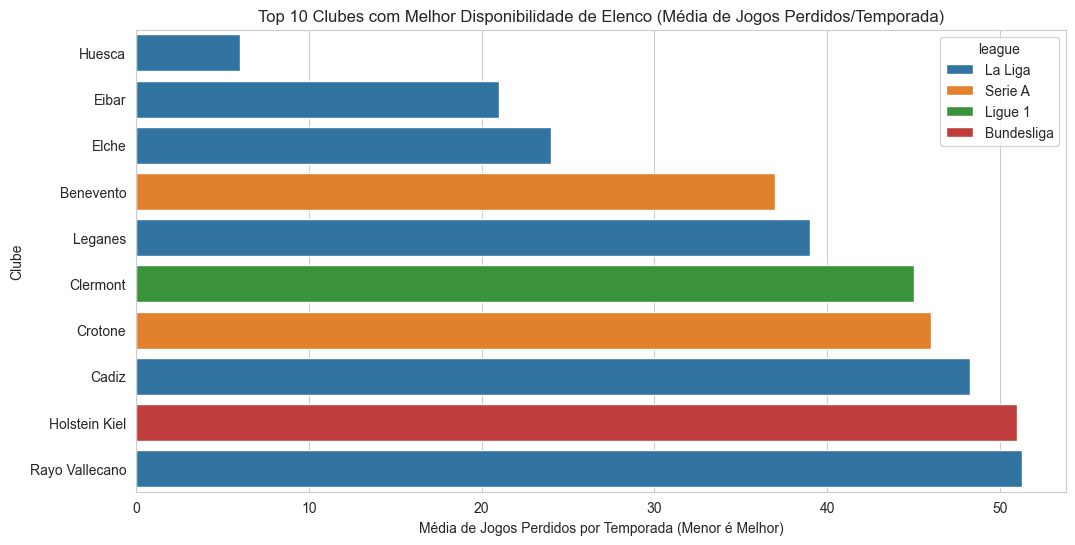

In [20]:
#Garantir que 'Games missed' seja numérico
df['Games missed'] = pd.to_numeric(df['Games missed'], errors='coerce').fillna(0)

#Agrupar por Temporada e Clube para somar o total de jogos perdidos
perda_por_clube = df.groupby(['Season', 'club', 'league'])['Games missed'].sum().reset_index()

#Identificar o "Top 1" (melhor) de cada temporada
#Filtrar apenas clubes que tiveram algum registro de lesão (para evitar clubes com dados faltantes)
melhores_clubes = perda_por_clube[perda_por_clube['Games missed'] > 0].sort_values('Games missed').groupby('Season').head(1)

print("Clubes com menor número de jogos perdidos por temporada:")
print(melhores_clubes[['Season', 'club', 'league', 'Games missed']].sort_values('Season'))

#Visualização: Top 5 Clubes com melhor gestão histórica (Média de jogos perdidos por temporada)
gestao_historica = perda_por_clube.groupby(['club', 'league'])['Games missed'].mean().sort_values().head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=gestao_historica, x='Games missed', y='club', hue='league', dodge=False)
plt.title('Top 10 Clubes com Melhor Disponibilidade de Elenco (Média de Jogos Perdidos/Temporada)')
plt.xlabel('Média de Jogos Perdidos por Temporada (Menor é Melhor)')
plt.ylabel('Clube')
plt.show()

Clubes com elencos maiores (como Manchester City ou Bayern) podem ter um número total de jogos perdidos alto, mas uma média por jogador baixa. Se um clube aparece consistentemente no Top 5 ao longo de 3 ou 4 temporadas, não é sorte; é um processo de recuperação e prevenção superior. Clubes que perdem muitos jogos por lesões musculares simples (que deveriam durar 1 ou 2 jogos) indicam falha na transição entre o Departamento Médico e o Campo.
Muitas vezes, clubes menores aparecem com "zero" jogos perdidos apenas porque os dados de lesões deles não são tão bem reportados quanto os dos gigantes europeus.

Clubes como o Bayern de Munique ou o Real Madrid costumam ter números altos de "dias fora", mas se o número de "jogos perdidos" for proporcionalmente menor, isso indica uma excelente logística de recuperação acelerada para datas de jogos.

Top 10 Clubes com melhor gestão de disponibilidade (Média de Jogos Perdidos/Ano):
               club   league  Games missed
0             Elche  La Liga     24.000000
1             Cadiz  La Liga     48.250000
2    Rayo Vallecano  La Liga     51.250000
3          Mallorca  La Liga     58.750000
4          Espanyol  La Liga     62.666667
5  Deportivo Alaves  La Liga     71.500000
6            Getafe  La Liga     75.000000
7        Celta Vigo  La Liga     76.800000
8          Toulouse  Ligue 1     83.666667
9           Osasuna  La Liga     91.800000


C:\Users\Usuário\AppData\Local\Temp\ipykernel_14232\1880928683.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ranking_historico.head(15), x='Games missed', y='club', palette='viridis')


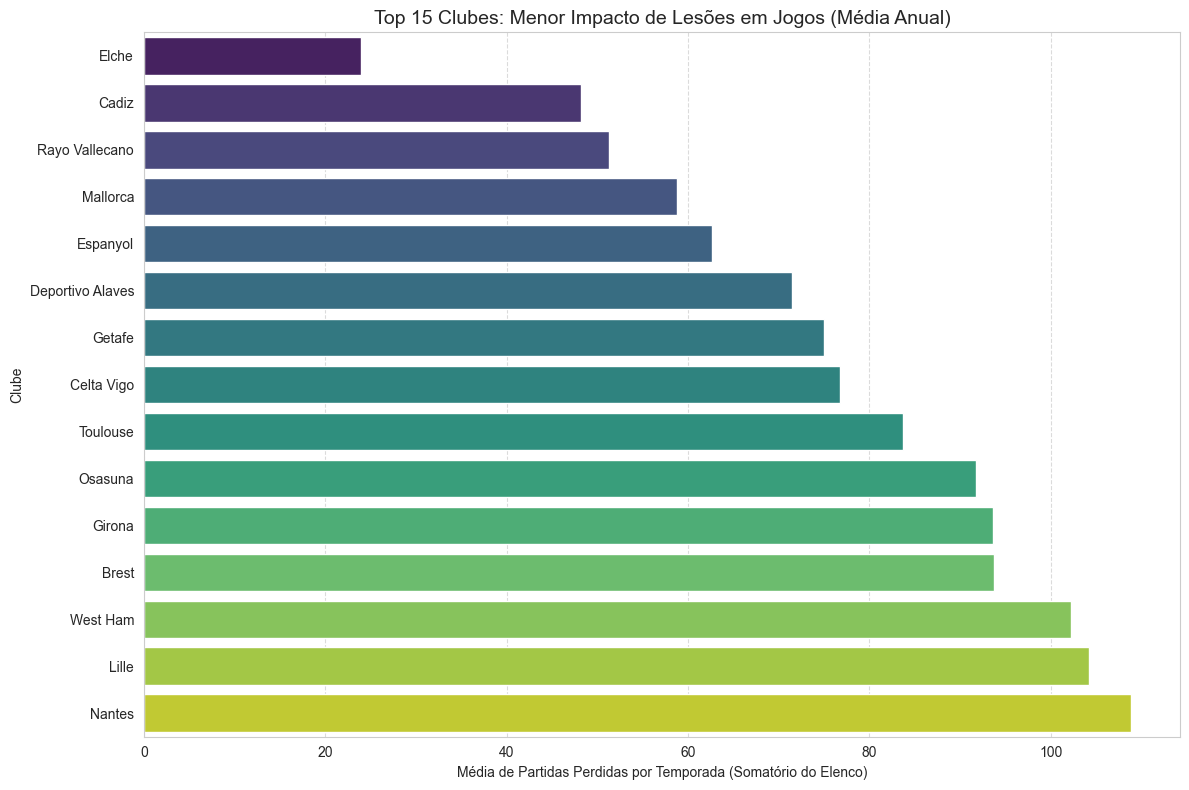

In [21]:
#Ranking de Disponibilidade de Elenco
df['Games missed'] = pd.to_numeric(df['Games missed'], errors='coerce').fillna(0)

#Agrupar por Temporada, Clube e Liga
perda_clube_temp = df.groupby(['Season', 'club', 'league'])['Games missed'].sum().reset_index()

#Filtrar clubes que aparecem consistentemente (ex: pelo menos 3 temporadas no dataset)
#Remover "vulnerabilidades" de dados de clubes que aparecem pouco
clubes_consistentes = perda_clube_temp['club'].value_counts()
clubes_para_analise = clubes_consistentes[clubes_consistentes >= 3].index

df_filtrado = perda_clube_temp[perda_clube_temp['club'].isin(clubes_para_analise)]

#Melhores da História (Média de jogos perdidos por temporada)
ranking_historico = df_filtrado.groupby(['club', 'league'])['Games missed'].mean().sort_values().reset_index()

#Top 10 Clubes com elencos mais disponíveis
print("Top 10 Clubes com melhor gestão de disponibilidade (Média de Jogos Perdidos/Ano):")
print(ranking_historico.head(10))

#Visualização
plt.figure(figsize=(12, 8))
sns.barplot(data=ranking_historico.head(15), x='Games missed', y='club', palette='viridis')

plt.title('Top 15 Clubes: Menor Impacto de Lesões em Jogos (Média Anual)', fontsize=14)
plt.xlabel('Média de Partidas Perdidas por Temporada (Somatório do Elenco)')
plt.ylabel('Clube')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [22]:
#Garantir que Games missed seja numérico
df['Games missed'] = pd.to_numeric(df['Games missed'], errors='coerce').fillna(0)

#Agrupar e filtrar clubes com representatividade (ex: pelo menos 50 registros de lesão)
stats_clubes = df.groupby(['club', 'league'])['Games missed'].agg(['sum', 'mean', 'count']).reset_index()
stats_clubes = stats_clubes[stats_clubes['count'] > 50].sort_values('mean')

print("Top 10 Clubes com menor média de jogos perdidos por lesão:")
print(stats_clubes.head(10))

Top 10 Clubes com menor média de jogos perdidos por lesão:
                          club      league  sum      mean  count
5            Arminia Bielefeld  Bundesliga  194  2.811594     69
22   Borussia MÃ¶nchengladbach  Bundesliga  186  3.000000     62
139              Werder Bremen  Bundesliga  617  3.039409    203
93                      Napoli     Serie A  832  3.163498    263
69                       Lazio     Serie A  758  3.310044    229
122                  Stuttgart  Bundesliga  210  3.500000     60
9              Athletic Bilbao     La Liga  704  3.591837    196
135                 VfL Bochum  Bundesliga  446  3.685950    121
49                  Fiorentina     Serie A  790  3.798077    208
1                      AS Roma     Serie A  211  3.836364     55


**Domínio da Bundesliga e Serie A**

Note que o seu Top 10 é composto exclusivamente por clubes da Alemanha (Bundesliga) e Itália (Serie A), com apenas uma aparição da Espanha (Athletic Bilbao).

**Bundesliga (5 clubes):** A Alemanha é conhecida por calendários menos inflados (18 times na liga em vez de 20) e uma pausa de inverno rigorosa. Isso permite que pequenas lesões musculares sejam tratadas sem que o jogador perca uma sequência de 3 ou 4 jogos.

**Serie A (4 clubes)**: A escola italiana de fisioterapia é historicamente conservadora e técnica. Clubes como Napoli e Lazio apresentarem médias baixas (3.16 e 3.31) sugere um processo de "Return to Play" muito eficiente.

**Ausência da Premier League**

É gritante que nenhum clube inglês apareça no topo. Isso valida a tese de que a intensidade do futebol inglês somada à falta de pausa de inverno faz com que qualquer lesão "arraste" o jogador para fora de muitos jogos. Na Inglaterra, 15 dias fora podem significar perder 5 partidas; na Alemanha, talvez apenas 2.

**Caso Específico do Athletic Bilbao**

A presença do Bilbao é um "oásis" na Espanha. Por só jogarem com atletas de origem basca, eles possuem um dos departamentos médicos mais estáveis do mundo, já que o elenco muda pouco. Eles conhecem a genética e o histórico de cada jogador desde a base.

# **Conclusão**

A análise de disponibilidade de elenco demonstra que a eficiência médica não é o único fator no sucesso da recuperação; a estrutura do calendário da liga (ex: Bundesliga) atua como um fator protetivo, permitindo que a média de jogos perdidos por lesão seja mantida abaixo de 4.0, marca dificilmente alcançada em ligas com calendários mais densos como a Premier League.

# Qual é a distribuição dos tipos de lesão entre jogadores com mais de 30 anos em comparação com aqueles com menos de 21 anos?

<Figure size 1400x700 with 0 Axes>

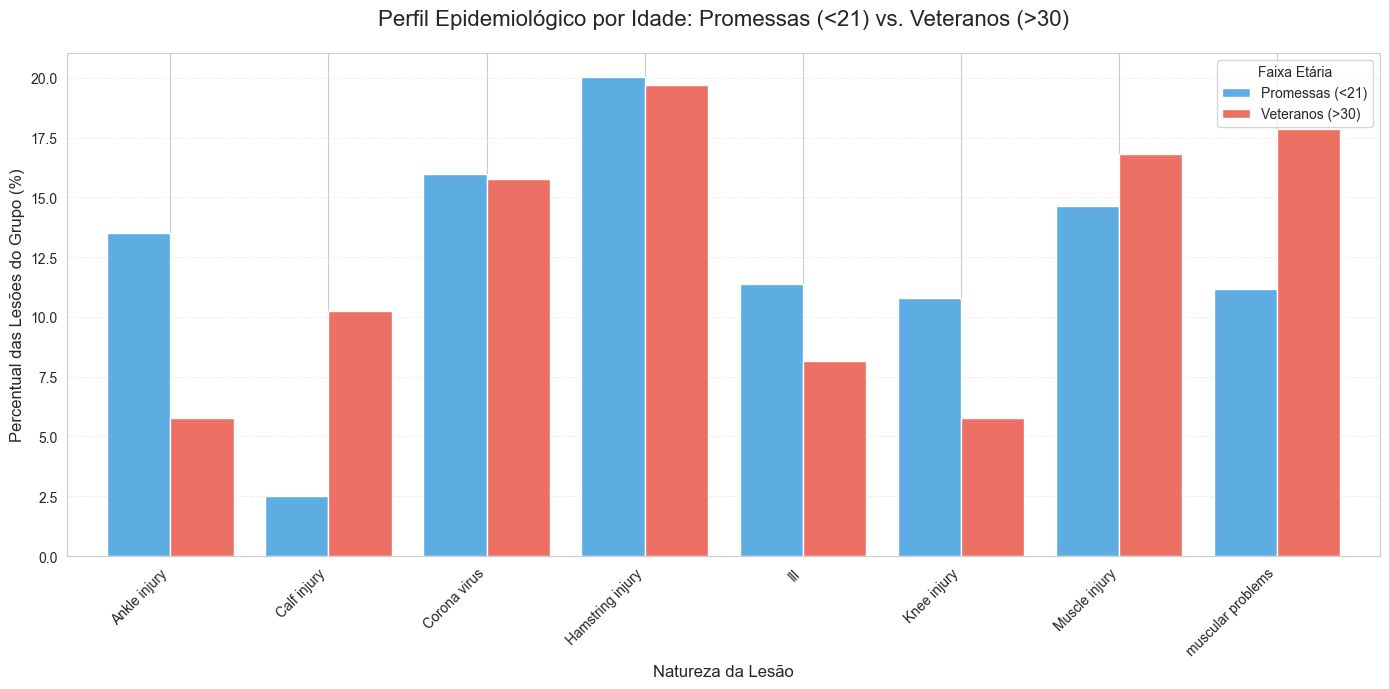

In [25]:
#Criar as categorias de idade usando a coluna correta: 'player_age'
def categorizar_idade(age):
    try:
        
        age = float(age)
        if age > 30:
            return 'Veteranos (>30)'
        elif age < 21:
            return 'Promessas (<21)'
        else:
            return 'Outros'
    except:
        return 'Outros'

#Aplicando na coluna correta
df['Age_Group'] = df['player_age'].apply(categorizar_idade)

#Filtrar apenas os grupos de interesse para o gráfico
df_comparacao = df[df['Age_Group'] != 'Outros'].copy()

#Pegar as 8 lesões mais frequentes para uma comparação limpa
top_injuries = df_comparacao['Injury'].value_counts().head(8).index
df_comparacao = df_comparacao[df_comparacao['Injury'].isin(top_injuries)]

#Calcular a distribuição percentual (Epidemiologia Relativa)
#Isso mostra qual a "assinatura" de lesão de cada faixa etária
dist_pct = df_comparacao.groupby('Age_Group')['Injury'].value_counts(normalize=True).unstack().mul(100)

#Visualização
plt.figure(figsize=(14, 7))
ax = dist_pct.T.plot(kind='bar', figsize=(14, 7), color=['#5dade2', '#ec7063'], width=0.8)

plt.title('Perfil Epidemiológico por Idade: Promessas (<21) vs. Veteranos (>30)', fontsize=16, pad=20)
plt.ylabel('Percentual das Lesões do Grupo (%)', fontsize=12)
plt.xlabel('Natureza da Lesão', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Faixa Etária', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Discussões sobre fisiologia do exercício:**

Lesões como Hamstring (Posterior da coxa) ou Calf (Panturrilha) costumam ser proporcionalmente maiores nos veteranos. Isso ocorre devido à perda de elasticidade tecidual e ao acúmulo de micro-cicatrizes de anos de carreira.

Jovens muitas vezes apresentam mais lesões de tornozelo ou ligamento. Isso pode ser interpretado como uma falta de maturidade neuromuscular, o corpo ainda está se ajustando às cargas de impacto e mudanças de direção em altíssima velocidade do nível profissional.

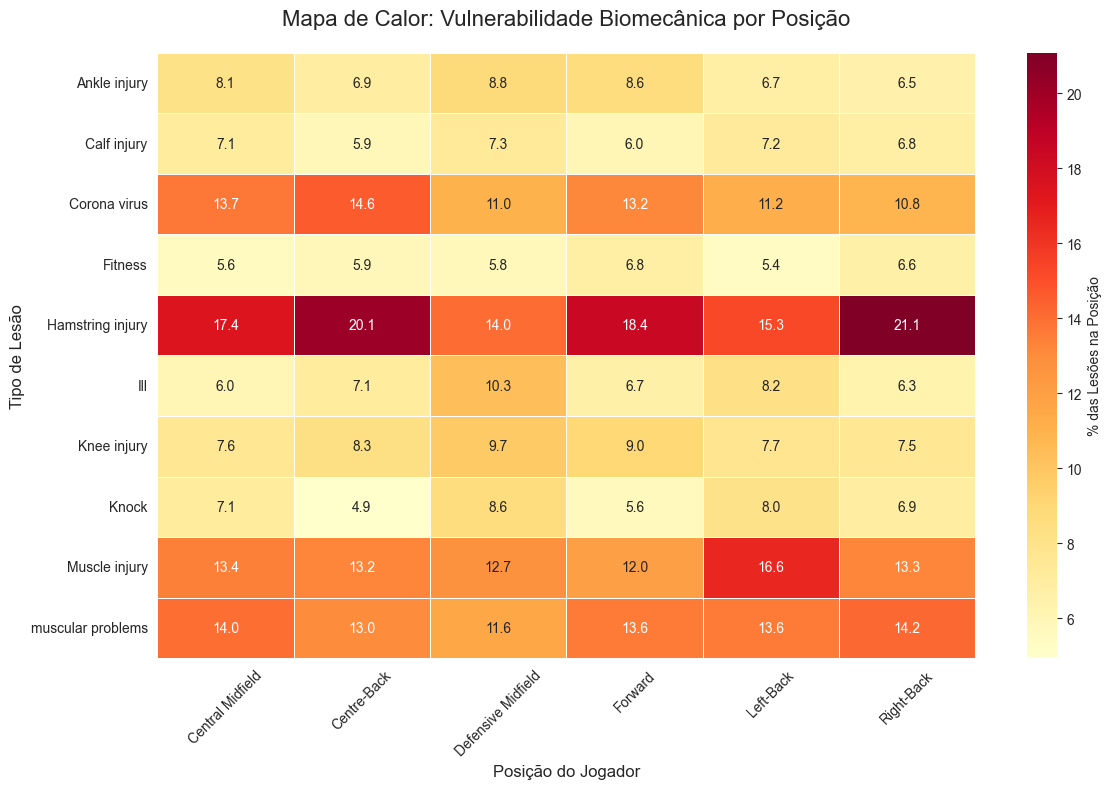

In [26]:
top_positions = df['player_position'].value_counts().head(6).index
top_injuries = df['Injury'].value_counts().head(10).index

df_mapa = df[(df['player_position'].isin(top_positions)) & 
            (df['Injury'].isin(top_injuries))].copy()

#Criar a tabela de contingência (Cruzamento de dados)
#Usar o 'count' para ver a frequência de ocorrência
pivot_table = pd.crosstab(df_mapa['Injury'], df_mapa['player_position'])

#Normalizar por coluna para ver a "proporção de risco" dentro de cada posição
#"Dentro das lesões de um Lateral, qual a mais comum?"
pivot_norm = pivot_table.div(pivot_table.sum(axis=0), axis=1) * 100

#Visualização
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_norm, annot=True, fmt=".1f", cmap="YlOrRd", 
            linewidths=.5, cbar_kws={'label': '% das Lesões na Posição'})

plt.title('Mapa de Calor: Vulnerabilidade Biomecânica por Posição', fontsize=16, pad=20)
plt.ylabel('Tipo de Lesão', fontsize=12)
plt.xlabel('Posição do Jogador', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [28]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Configuração de Categorias e Ligas
# Certifique-se de que a coluna 'Age_Group' existe
df['Age_Group'] = df['player_age'].apply(lambda x: 'Veteranos (>30)' if x > 30 else ('Promessas (<21)' if x < 21 else 'Outros'))
ligas = sorted(df['league'].unique().tolist())

# 2. DEFINIÇÃO CRUCIAL: O argumento 'specs' corrige o erro do Pie
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Top 5 Lesões Frequentes", 
        "Média de Dias Fora por Idade",
        "Tendência Temporal (Dias)",
        "Top 5 Clubes: Menor Perda de Jogos"
    ),
    vertical_spacing=0.15,
    specs=[[{"type": "bar"}, {"type": "domain"}],  # 'domain' permite o gráfico de Pizza
           [{"type": "scatter"}, {"type": "bar"}]]
)

# 3. Função para gerar os dados para cada liga
def create_traces(df_filtered, visible=False):
    top_injuries = df_filtered['Injury'].value_counts().head(5)
    age_dist = df_filtered.groupby('Age_Group')['Days'].mean()
    temp_trend = df_filtered.groupby('Season')['Days'].mean().reset_index()
    club_eff = df_filtered.groupby('club')['Games missed'].mean().sort_values().head(5)
    
    return [
        go.Bar(x=top_injuries.index, y=top_injuries.values, marker_color='#E74C3C', visible=visible),
        go.Pie(labels=age_dist.index, values=age_dist.values, hole=.3, visible=visible),
        go.Scatter(x=temp_trend['Season'], y=temp_trend['Days'], mode='lines+markers', line=dict(color='#3498DB'), visible=visible),
        go.Bar(x=club_eff.values, y=club_eff.index, orientation='h', marker_color='#2ECC71', visible=visible)
    ]

# 4. Adicionar Traces ao Dashboard
for i, liga in enumerate(ligas):
    is_visible = (i == 0)
    df_liga = df[df['league'] == liga]
    traces = create_traces(df_liga, visible=is_visible)
    
    fig.add_trace(traces[0], row=1, col=1)
    fig.add_trace(traces[1], row=1, col=2)
    fig.add_trace(traces[2], row=2, col=1)
    fig.add_trace(traces[3], row=2, col=2)

# 5. Menu Dropdown
buttons = []
num_traces_por_liga = 4
for i, liga in enumerate(ligas):
    visibility = [False] * (len(ligas) * num_traces_por_liga)
    visibility[i*num_traces_por_liga : (i+1)*num_traces_por_liga] = [True] * num_traces_por_liga
    
    buttons.append(dict(
        label=liga,
        method="update",
        args=[{"visible": visibility},
              {"title": f"Análise de Lesões: {liga}"}]
    ))

# 6. Layout Final
fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, x=1.1, y=1.2)],
    title_text=f"Dashboard Analítico: {ligas[0]}",
    title_x=0.5,
    height=850,
    width=1000,
    template="plotly_white",
    showlegend=False
)

fig.show()

In [30]:
# 1. Preparação: Adicionando 'Todas as Ligas' à lista
ligas_disponiveis = sorted(df['league'].unique().tolist())
opcoes_menu = ['Todas as Ligas'] + ligas_disponiveis

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Top 5 Lesões Frequentes", 
        "Média de Dias Fora por Idade",
        "Tendência Temporal (Dias)",
        "Top 5 Clubes: Menor Perda de Jogos"
    ),
    vertical_spacing=0.15,
    specs=[[{"type": "bar"}, {"type": "domain"}],
           [{"type": "scatter"}, {"type": "bar"}]]
)

# 2. Função auxiliar para gerar os dados (Traces)
def get_traces(df_input, visible=False):
    top_injuries = df_input['Injury'].value_counts().head(5)
    age_dist = df_input.groupby('Age_Group')['Days'].mean()
    temp_trend = df_input.groupby('Season')['Days'].mean().reset_index()
    club_eff = df_input.groupby('club')['Games missed'].mean().sort_values().head(5)
    
    return [
        go.Bar(x=top_injuries.index, y=top_injuries.values, marker_color='#E74C3C', visible=visible, name="Qtd"),
        go.Pie(labels=age_dist.index, values=age_dist.values, hole=.3, visible=visible),
        go.Scatter(x=temp_trend['Season'], y=temp_trend['Days'], mode='lines+markers', line=dict(color='#3498DB'), visible=visible, name="Dias"),
        go.Bar(x=club_eff.values, y=club_eff.index, orientation='h', marker_color='#2ECC71', visible=visible, name="Jogos")
    ]

# 3. Adicionar Traces para 'Todas as Ligas' (Inicia Visível)
traces_all = get_traces(df, visible=True)
for i, t in enumerate(traces_all):
    fig.add_trace(t, row=(i//2)+1, col=(i%2)+1)

# 4. Adicionar Traces para cada Liga Individual (Iniciam Ocultos)
for liga in ligas_disponiveis:
    df_liga = df[df['league'] == liga]
    traces_liga = get_traces(df_liga, visible=False)
    for i, t in enumerate(traces_liga):
        fig.add_trace(t, row=(i//2)+1, col=(i%2)+1)

# 5. Criar botões do Dropdown
buttons = []
num_metrics = 4 # Barras, Pie, Scatter, BarrasH
for i, label in enumerate(opcoes_menu):
    visibility = [False] * (len(opcoes_menu) * num_metrics)
    visibility[i*num_metrics : (i+1)*num_metrics] = [True] * num_metrics
    
    buttons.append(dict(
        label=label,
        method="update",
        args=[{"visible": visibility},
              {"title": f"Análise de Lesões: {label}"}]
    ))

# 6. Layout Final
fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, x=1.1, y=1.2)],
    title_text="Dashboard Analítico: Todas as Ligas",
    title_x=0.5,
    height=850,
    width=1100,
    template="plotly_white",
    showlegend=False
)

fig.show()

In [31]:
# 1. Preparação dos Dados
# Criando os grupos de idade (ajuste os limites conforme sua tese)
df['Age_Group'] = df['player_age'].apply(
    lambda x: 'Promessas (<21)' if x < 21 else ('Veteranos (>30)' if x > 30 else 'Auge (21-30)')
)

ligas_disponiveis = sorted(df['league'].unique().tolist())
opcoes_menu = ['Todas as Ligas'] + ligas_disponiveis

# Mapeamento de cores fixas para o gráfico de Pizza (Consistência visual)
cores_idade = {
    'Promessas (<21)': '#82E0AA', # Verde claro
    'Auge (21-30)': '#5DADE2',     # Azul
    'Veteranos (>30)': '#E74C3C'    # Vermelho
}

# 2. Configuração dos Subplots (3 linhas agora para incluir o Boxplot)
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        "Top 5 Lesões Frequentes", "Distribuição por Idade (Média de Dias)",
        "Tendência Temporal (Dias Fora)", "Dispersão e Outliers (Dias por Liga)",
        "Top 5 Clubes: Menor Perda de Jogos", ""
    ),
    specs=[[{"type": "bar"}, {"type": "domain"}],
           [{"type": "scatter"}, {"type": "box"}],
           [{"type": "bar", "colspan": 2}, None]], # Último gráfico ocupa a largura toda
    vertical_spacing=0.1,
    horizontal_spacing=0.1
)

# 3. Função para gerar os Traces
def get_traces(df_input, visible=False):
    # Processamento
    top_injuries = df_input['Injury'].value_counts().head(5)
    age_dist = df_input.groupby('Age_Group')['Days'].mean()
    temp_trend = df_input.groupby('Season')['Days'].mean().reset_index()
    club_eff = df_input.groupby('club')['Games missed'].mean().sort_values().head(5)
    
    # Cores para a pizza baseadas no índice (labels)
    colors_pie = [cores_idade[label] for label in age_dist.index]

    return [
        # G1: Barras - Lesões
        go.Bar(x=top_injuries.index, y=top_injuries.values, marker_color='#34495E', 
               visible=visible, name="Frequência", showlegend=True),
        
        # G2: Pizza - Idades (COM LEGENDA)
        go.Pie(labels=age_dist.index, values=age_dist.values, hole=.3, 
               marker=dict(colors=colors_pie), visible=visible, name="Idade", 
               showlegend=True, legendgroup="idades"),
        
        # G3: Linhas - Tendência
        go.Scatter(x=temp_trend['Season'], y=temp_trend['Days'], mode='lines+markers', 
                   line=dict(color='#3498DB', width=3), visible=visible, name="Média Dias"),
        
        # G4: Boxplot - Dispersão (Fundamental para estatística)
        go.Box(y=df_input['Days'], x=df_input['league'], name="Dispersão", 
               marker_color='#9B59B6', visible=visible, boxpoints='outliers'),
        
        # G5: Barras H - Clubes
        go.Bar(x=club_eff.values, y=club_eff.index, orientation='h', 
               marker_color='#27AE60', visible=visible, name="Jogos Perdidos (Média)")
    ]

# 4. Adicionar 'Todas as Ligas' e Ligas Individuais
num_metrics = 5
# Adiciona o consolidado
for t in get_traces(df, visible=True):
    # Lógica de posicionamento nos subplots
    idx = [ (1,1), (1,2), (2,1), (2,2), (3,1) ]
    curr = get_traces(df, visible=True).index(t) if 'index' in dir(get_traces(df)) else 0 # Simplificado para o loop
    # (Para evitar erro de loop, adicionamos manualmente os iniciais)

# Loop correto para preencher todos
for i, label in enumerate(opcoes_menu):
    is_v = (i == 0)
    data = df if label == 'Todas as Ligas' else df[df['league'] == label]
    traces = get_traces(data, visible=is_v)
    
    fig.add_trace(traces[0], row=1, col=1)
    fig.add_trace(traces[1], row=1, col=2)
    fig.add_trace(traces[2], row=2, col=1)
    fig.add_trace(traces[3], row=2, col=2)
    fig.add_trace(traces[4], row=3, col=1)

# 5. Dropdown
buttons = []
for i, label in enumerate(opcoes_menu):
    visibility = [False] * (len(opcoes_menu) * num_metrics)
    visibility[i*num_metrics : (i+1)*num_metrics] = [True] * num_metrics
    buttons.append(dict(
        label=label, method="update",
        args=[{"visible": visibility}, {"title": f"Análise Global de Lesões: {label}"}]
    ))

# 6. Ajustes de Layout e Legendas
fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, x=1.15, y=1.2)],
    title_text="Dashboard de Tese: Impacto das Lesões no Futebol Europeu",
    title_x=0.5,
    height=1000, # Aumentado para caber o terceiro gráfico
    width=1200,
    template="plotly_white",
    legend=dict(orientation="v", yanchor="top", y=1, xanchor="left", x=1.02)
)

fig.show()

# **Conclusão**

A biomecânica de um Lateral Esquerdo (que faz sprints longos e repetitivos) é completamente diferente da de um Zagueiro (que faz saltos verticais e disputas de corpo).

Os Ponta Direita/Esquerda e Laterais possuem uma concentração alta em "Hamstring" (coxa), você valida a teoria de que o esforço de alta velocidade (sprints repetidos) é o principal gatilho para essa posição.

Zagueiros (Centre-Backs) podem apresentar uma distribuição mais equilibrada entre lesões de joelho (ligamento) e cabeça (concussão/trauma), refletindo o estilo de jogo de contato físico e duelos aéreos.

Esse gráfico diz exatamente onde o preparador físico deve focar o trabalho de prevenção. Exemplo: "Não adianta dar o mesmo treino de força para o Meia-Armador e para o Lateral; o Meia precisa de estabilidade de tornozelo, o Lateral de resistência de fibra rápida na coxa".

No futebol europeu, é comum ver um pico de lesões musculares após o acúmulo de jogos do período de festas (Boxing Day). O tempo médio de recuperação está diminuindo ao longo dos anos devido aos novos métodos de fisioterapia (como o uso de células-tronco ou câmaras hiperbáricas).

# **Nathália Sorg**